In [ ]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document

from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import anthropic

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, make_message_langchain_compatible
from dotenv import load_dotenv
import os
import voyageai

In [6]:
load_dotenv()
VOYAGE_API_KEY = os.environ.get("VOYAGE_API_KEY")
voyageai_client = voyageai.Client(api_key=VOYAGE_API_KEY)
qdrant_client = QdrantClient(url="http://localhost:6333")

def get_embedding(text, model='voyage-3', input_type="document"):
        result = voyageai_client.embed(
                [text],
                model=model,
                input_type=input_type
        )
        return result.embeddings[0]

In [7]:
def retrieve_data(query, qdrant_client, k=5):
        query_embedding = get_embedding(query)
        results = qdrant_client.query_points(
                collection_name="Amazon-items-collection-01-hybrid-search",
                prefetch=[
                        Prefetch(
                                query=query_embedding,
                                using='voyage-3',
                                limit=10,
                        ),
                        Prefetch(
                                query=Document(
                                        text=query,
                                        model="qdrant/bm25"
                                ),
                                using='bm25',
                                limit=10,
                        ),
                ],
                query=FusionQuery(fusion='rrf'), #reciprocal rank fusion
                limit=k,
        )

        retrieved_context_ids = []
        retrieved_context = []
        similarity_scores = []
        retrieved_context_ratings = []

        for item in results.points:
                retrieved_context_ids.append(item.payload['parent_asin'])
                retrieved_context.append(item.payload['description'])
                retrieved_context_ratings.append(item.payload['average_rating'])
                similarity_scores.append(item.score)
        
        return {
                "retrieved_context_ids": retrieved_context_ids,
                "retrieved_context": retrieved_context,
                "retrieved_context_ratings": retrieved_context_ratings,
                "similarity_scores": similarity_scores,
        }

In [8]:
query = "Can I get a tablet"
retrieve_data(query, qdrant_client, k=10)

{'retrieved_context_ids': ['B08JCX7MB7',
  'B09V28Y3HH',
  'B09Z6F54Y3',
  'B0BN58Z4YX',
  'B0BLMWXBDY',
  'B09PL3WQHB',
  'B0BK91PLJG',
  'B09ZJ9LKCN',
  'B0BKPTRBNT',
  'B0B4WNFTVZ'],
 'retrieved_context': ['Low Rated iPad Cases (26) ',
  'CIYUPE Tablet Pillow Stand, Tablet Holder Dock for Bed with 6 Viewing Angles, Compatible with iPad Pro 9.7, 10.5,12.9 Air Mini 4 3, Kindle, Galaxy Tab, E-Reader and Books (Grey) 【 COMPATIBILITY 】 Universal tablet stand pillow suitable to iPad and tablets between 4.7 and 13 inches, like new iPad Air 4, 2021 iPad Pro 11, 2020 iPad Pro 11 / 12.9 inch, 2018 iPad Pro 10.5 inch, iPad Air, iPad Mini, Kindle Fire HD 7 8 10, E-reader, iPhone X, iPhone 8 plus, iPhone 13, iPhone 13 Pro Max, iPhone 12 Pro Max, iPhone 11, Surface Pro, Galaxy Tab, Switch. 【6 Viewing Angles】 This multi angle pillow i pad tablet stand has 6 angle adjustment, provides a best viewing angle in the bed, sofa or table, supporting both vertical and horizontal viewing. A deeper groove su

# Multi Intent Questions

In [ ]:
query = "Can I get a tablet for my kid, a watch for me and laptop for my wife"
retrieve_data(query, qdrant_client, k=10) # the answer wont be very good

{'retrieved_context_ids': ['B0BN58Z4YX',
  'B08JCX7MB7',
  'B09Z6F54Y3',
  'B0C1NM3S2D',
  'B0BGP3P33P',
  'B0B7H637FL',
  'B0B157WDDJ',
  'B0BLMWXBDY',
  'B0BHVF13PY',
  'B09ZJ9LKCN'],
 'retrieved_context': ['ASWINN Tablet Tripod Stand, Gooseneck 65" Height Adjustable Tablet Stand Floor with 360° Rotating Tripod Mount Suitable for iPhone,Tablet,Kindle and All 4.5-12.9 Inch Tablet and Phone (Black) 【Free Your Hands】: With this gooseneck arm tablet tripod stand, you can find a more comfortable way to use tablet & Phone in bed or sofa in winter. Release your hands while make your leisure time more enjoyable，the best Christmas gift or New Year gifts for wife,husband,elders,friend or colleague. 【Versatile Gooseneck Tablet Tripod Stand】This ergonomic gooseneck tablet holder suits most tablets and phones. you can easily get your desired angle to meet your needs at different angles and positions. Except for watching movies, you are also allowed to use your tablet for visual presentations, lik

In [ ]:
class QueryExpandResponse(BaseModel):
        statements: List[str]

In [14]:
# Node for query decomposition
def query_expand_node(query) -> dict:
        system_prompt = """
                You are part of a shopping assistant that can answer questions about products in stock.

                Instructions:
                - You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
                - The statements should not overlap in context.
        """

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=QueryExpandResponse,
                max_tokens=8096,
                system=system_prompt,
                messages=[
                        {"role": "user", "content": query}
                ],
                temperature=0.5,
        )

        return {
                "queries": response.statements
        }

In [ ]:
answer = query_expand_node(query)

# Langgraph

In [35]:
class  State(BaseModel):
        expanded_query: List[str] = []
        retrieved_context: Annotated[List[str], add] = []
        initial_query: str = ""
        answer: str = ""

class QueryExpandResponse(BaseModel):
        expanded_query: List[str]

class AggregatorResponse(BaseModel):
        answer: str = Field(description="Answer to the query")

### Query Expention / Rewrite Node

In [41]:
@traceable(
        name="agent_node",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def query_expand_node(state: State) -> dict:
        system_prompt = """
                You are part of a shopping assistant that can answer questions about products in stock.

                Instructions:
                - You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
                - The statements should not overlap in context.
        """

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=QueryExpandResponse,
                max_tokens=8096,
                system=system_prompt,
                messages=[
                        {"role": "user", "content": state.initial_query}
                ],
                temperature=0.5,
        )

        return {
                "expanded_query": response.expanded_query
        }

### Retriever Node

In [46]:
@traceable(
        name="embed_query",
        run_type="embedding",
        metadata={"ls_provider": "voyageai", "ls_model_name": "voyage-3"},
)
def get_embedding(text, model='voyage-3', input_type="document"):
        result = voyageai_client.embed(
                [text],
                model=model,
                input_type=input_type
        )
        return result.embeddings[0]


@traceable(
        name="retrieve_top_n",
        run_type="retriever",
)
def retrieve_data(query, k=5):
        query_embedding = get_embedding(query)
        qdrant_client = QdrantClient(url="http://localhost:6333")
        results = qdrant_client.query_points(
                collection_name="Amazon-items-collection-01-hybrid-search",
                prefetch=[
                        Prefetch(
                                query=query_embedding,
                                using='voyage-3',
                                limit=10,
                        ),
                        Prefetch(
                                query=Document(
                                        text=query,
                                        model="qdrant/bm25"
                                ),
                                using='bm25',
                                limit=10,
                        ),
                ],
                query=FusionQuery(fusion='rrf'), #reciprocal rank fusion
                limit=k,
        )

        retrieved_context_ids = []
        retrieved_context = []
        similarity_scores = []
        retrieved_context_ratings = []

        for item in results.points:
                retrieved_context_ids.append(item.payload['parent_asin'])
                retrieved_context.append(item.payload['description'])
                retrieved_context_ratings.append(item.payload['average_rating'])
                similarity_scores.append(item.score)

        formatted_context = ""
        for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
                formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
        
        return formatted_context


@traceable(
        name="retriever_node",
        run_type="retriever",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def retrieve_node(state: State) -> dict:
        retrieved_context = []
        for query in state.expanded_query:
                retrieved_context.append(retrieve_data(query, k=10))
        
        return {
                "retrieved_context": retrieved_context
        }

### Aggregator Node

In [47]:
@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def aggregator_node(state: State) -> dict:
        prompt_template = """
                You are a shopping assistant that can answer questions about the products in stock.
                You will be given a question and a list of context.

                Instructions:
                - You need to answer the question based on the provided context only.
                - Never use word context and refer to it as the available products.
                - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

                Context:
                {{ preprocessed_context }}

                Question:
                {{ question }}
        """

        template = Template(prompt_template)
        prompt = template.render(
                preprocessed_context = '\n'.join(state.retrieved_context),
                question = state.initial_query,
        )

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())
        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=AggregatorResponse,
                max_tokens=8096,
                system=prompt,
                messages=[
                        {"role": "user", "content": "Solve for the requirement"}
                ],
                temperature=0.5,
        )

        return {
                "answer": response.answer
        }

### Graph

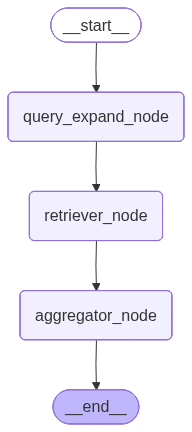

In [48]:
workflow = StateGraph(State)

# Add nodes
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)

# Add edges
workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [49]:
initial_state = {
        "initial_query": query,
}
result = graph.invoke(initial_state)
result

{'expanded_query': ['tablet for kids', 'watch for adults', 'laptop for women'],
 'retrieved_context': ['- ID: B08JCX7MB7, rating: 4.6, description: Low Rated iPad Cases (26) \n- ID: B0B157WDDJ, rating: 3.9, description: G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink 🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE\'s exclusive kids tablet case is made of impact-resistant EVA material. When

In [52]:
print(result['answer'])

Based on the available products, I can help you with a tablet for your kid and a laptop bag for your wife. However, I must note that we don't have a watch available in our current inventory.

**For Your Kid - Kids Tablets Available:**

1. **G-TiDE Kids Tablet (ID: B0B157WDDJ)** - Rating: 3.9
   • 7-inch display designed for kids aged 3-7 years
   • 32GB storage (expandable to 128GB with micro SD card)
   • 5MP dual camera with HD quality
   • Kids-proof case made of impact-resistant EVA material
   • 270° adjustable stand for comfortable viewing
   • Parental control app (KLAP) with 20+ child accounts
   • Features: child lock, remote video control, content filtering, time limits
   • Pre-installed learning and entertainment apps
   • Adjustable shoulder strap for portability
   • 12-month worry-free guarantee

2. **CUPEISI Kids Tablet (ID: B0C1NM3S2D)** - Rating: 4.0
   • 7-inch WiFi tablet with Android 11.0 OS
   • 32GB ROM + 2GB RAM (expandable to 128GB)
   • Quad-core processor wit

# Query Expansion (Parallel Execution)

In [56]:
class  State(BaseModel):
        expanded_query: List[str] = []
        retrieved_context: Annotated[List[str], add] = []
        initial_query: str = ""
        answer: str = ""
        query: str = ""
        k: int = 10


### Query Expansion Node

In [57]:
@traceable(
        name="agent_node_parallel",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def query_expand_node(state: State) -> dict:
        system_prompt = """
                You are part of a shopping assistant that can answer questions about products in stock.

                Instructions:
                - You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
                - The statements should not overlap in context.
        """

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=QueryExpandResponse,
                max_tokens=8096,
                system=system_prompt,
                messages=[
                        {"role": "user", "content": state.initial_query}
                ],
                temperature=0.5,
        )

        return {
                "expanded_query": response.expanded_query
        }

### Edge for parallel execution

In [58]:
def query_expand_conditional_edge_for_parallel_execution(state: State):
        send_messages = []
        for query in state.expanded_query:
                send_messages.append(
                        Send(
                                'retriever_node', # which node the broadcast will be done
                                {
                                        'query': query, # local states for this broadcast since these will be parallel
                                        'k':10,
                                }
                        )
                )
        return send_messages


### Retriever Node

In [59]:
@traceable(
        name="embed_query",
        run_type="embedding",
        metadata={"ls_provider": "voyageai", "ls_model_name": "voyage-3"},
)
def get_embedding(text, model='voyage-3', input_type="document"):
        result = voyageai_client.embed(
                [text],
                model=model,
                input_type=input_type
        )
        return result.embeddings[0]


@traceable(
        name="retrieve_top_n",
        run_type="retriever",
)
def retrieve_data(query, k=5):
        query_embedding = get_embedding(query)
        qdrant_client = QdrantClient(url="http://localhost:6333")
        results = qdrant_client.query_points(
                collection_name="Amazon-items-collection-01-hybrid-search",
                prefetch=[
                        Prefetch(
                                query=query_embedding,
                                using='voyage-3',
                                limit=10,
                        ),
                        Prefetch(
                                query=Document(
                                        text=query,
                                        model="qdrant/bm25"
                                ),
                                using='bm25',
                                limit=10,
                        ),
                ],
                query=FusionQuery(fusion='rrf'), #reciprocal rank fusion
                limit=k,
        )

        retrieved_context_ids = []
        retrieved_context = []
        similarity_scores = []
        retrieved_context_ratings = []

        for item in results.points:
                retrieved_context_ids.append(item.payload['parent_asin'])
                retrieved_context.append(item.payload['description'])
                retrieved_context_ratings.append(item.payload['average_rating'])
                similarity_scores.append(item.score)

        formatted_context = ""
        for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
                formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
        
        return formatted_context


@traceable(
        name="retriever_node",
        run_type="retriever",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def retrieve_node(state: State) -> dict:
        retrieved_context = retrieve_data(state['query'], state['k'])
        return {
                "retrieved_context": [retrieved_context]
        }

### Aggregator Node

In [60]:
class AggregatorResponse(BaseModel):
        answer: str = Field(description="Answer to the query")

@traceable(
        name="query_expand_node",
        run_type="llm",
        metadata={"ls_provider": "anthropic", "ls_model_name": "claude-haiku-4-5-20251001"},
)
def aggregator_node(state: State) -> dict:
        prompt_template = """
                You are a shopping assistant that can answer questions about the products in stock.
                You will be given a question and a list of context.

                Instructions:
                - You need to answer the question based on the provided context only.
                - Never use word context and refer to it as the available products.
                - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

                Context:
                {{ preprocessed_context }}

                Question:
                {{ question }}
        """

        template = Template(prompt_template)
        prompt = template.render(
                preprocessed_context = '\n'.join(state.retrieved_context),
                question = state.initial_query,
        )

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())
        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=AggregatorResponse,
                max_tokens=8096,
                system=prompt,
                messages=[
                        {"role": "user", "content": "Solve for the requirement"}
                ],
                temperature=0.5,
        )

        return {
                "answer": response.answer
        }

### graph

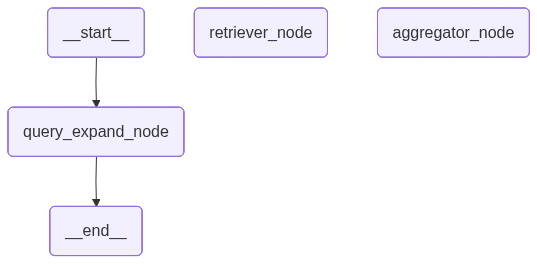

In [61]:
workflow = StateGraph(State)

# Add nodes
workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)

# Add edges
workflow.add_edge(START, "query_expand_node")
workflow.add_conditional_edges(
        "query_expand_node",
        query_expand_conditional_edge_for_parallel_execution
)
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
initial_state = {
        "initial_query": query,
}
result = graph.invoke(initial_state)
result

{'expanded_query': ['tablet for kids', 'watch for adults', 'laptop for women'],
 'retrieved_context': ['- ID: B0B157WDDJ, rating: 3.9, description: G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink 🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE\'s exclusive kids tablet case is made of impact-resistant EVA material. When your kid is playing outdoors with the tablet or accidentally dropping t

In [63]:
print(result['answer'])

Based on the available products, I can help you with a tablet for your kid and a laptop bag for your wife. However, I must inform you that **we do not have watches available** in our current inventory.

Here's what I can offer:

## **For Your Kid - Kids Tablets Available:**

### **1. G-TiDE Kids Tablet (ID: B0B157WDDJ) - Rating: 3.9/5**
- **Screen Size:** 7 inches
- **Storage:** 32GB + 2GB RAM (expandable up to 128GB with micro SD card)
- **Camera:** 5MP Dual Camera HD
- **Display:** HD Screen with eye-protection features
- **Operating System:** Android with Google Play Store access
- **Features:**
  - Pre-installed KLAP kids app with brain training, painting, gaming, and kids TV
  - Kids-proof EVA material case with impact-resistant protection
  - Adjustable shoulder strap for portability
  - 270° adjustable stand
  - Parental controls (20+ child accounts, content filtering, time limits, child lock)
  - Perfect for ages 3-7 years
  - 12-month worry-free guarantee

### **2. CUPEISI Kid